<a href="https://colab.research.google.com/github/sardar-ammad-143/Basic-Python/blob/main/final%20project%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow/Keras for model building
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping


In [3]:
# Load the dataset
file_path = "/content/sample_data/edited .csv"  # Replace with your dataset file path
data = pd.read_csv(file_path)

# Display the first few rows
print(data.head())

# Check dataset information
print("Dataset Shape:", data.shape)
print(data.info())

# Check for missing values
print("Missing Values:\n", data.isnull().sum())


   PM2.5    PM10    NO    NO2    NOx    NH3   CO    SO2      O3  Benzene  \
0  60.50   98.00  2.35  30.80  18.25   8.50  0.1  11.85  126.40      0.1   
1  65.50  111.25  2.70  24.20  15.07   9.77  0.1  13.17  117.12      0.1   
2  80.00  132.00  2.10  25.18  15.15  12.02  0.1  12.08   98.98      0.2   
3  81.50  133.25  1.95  16.25  10.23  11.58  0.1  10.47  112.20      0.2   
4  75.25  116.00  1.43  17.48  10.43  12.03  0.1   9.12  106.35      0.2   

   Toluene  Xylene  AQI  
0     6.10    0.10  NaN  
1     6.25    0.15  NaN  
2     5.98    0.18  NaN  
3     6.72    0.10  NaN  
4     5.75    0.08  NaN  
Dataset Shape: (1048575, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 13 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PM2.5    800186 non-null  float64
 1   PM10     705840 non-null  float64
 2   NO       817926 non-null  float64
 3   NO2      831443 non-null  float64
 4   NOx   

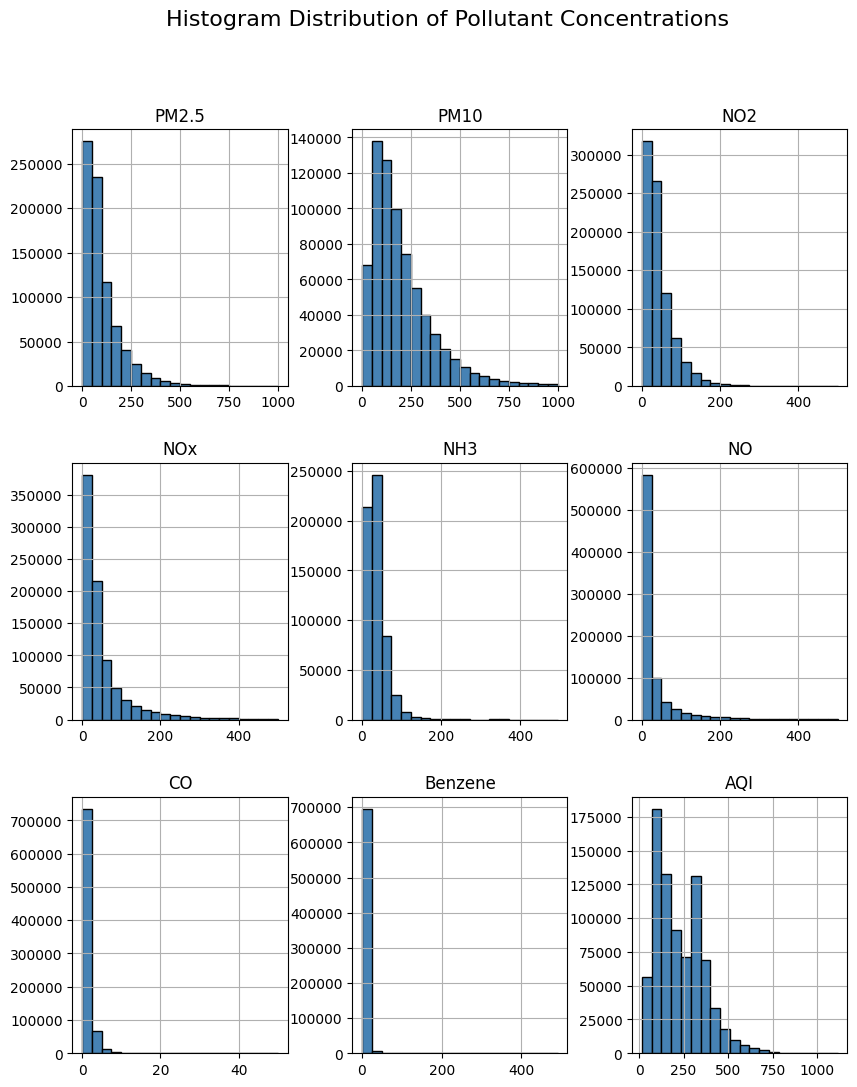

In [6]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'NOx', 'NH3', 'NO', 'CO', 'Benzene', 'AQI']
data[pollutants].hist(figsize=(10, 12), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Histogram Distribution of Pollutant Concentrations', fontsize=16)
plt.show()


In [7]:
# Fill missing values with the column mean
data.fillna(data.mean(), inplace=True)


In [8]:
# Initialize Min-Max Scaler
scaler = MinMaxScaler()

# Apply Min-Max Scaling
data_normalized = scaler.fit_transform(data)
data = pd.DataFrame(data_normalized, columns=data.columns)

# Save the scaler for future use
import joblib
joblib.dump(scaler, 'min_max_scaler.pkl')


['min_max_scaler.pkl']

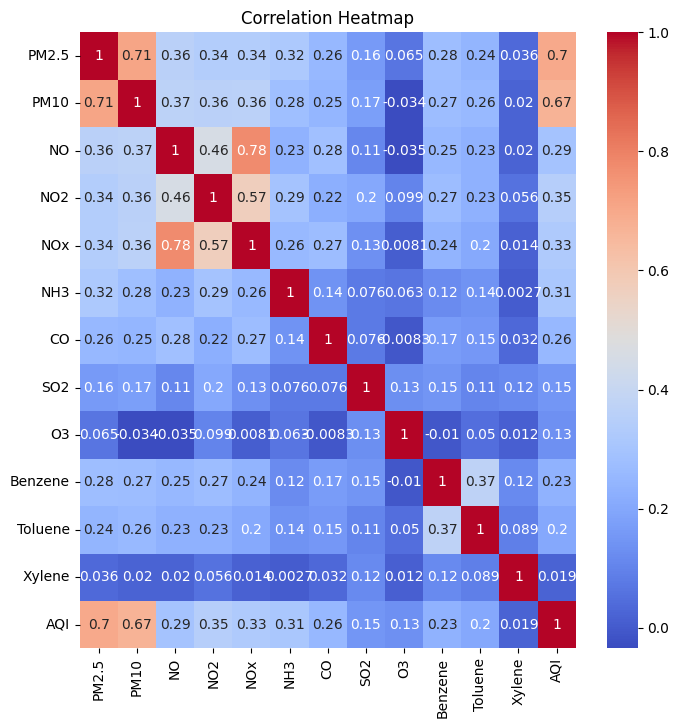

AQI        1.000000
PM2.5      0.699242
PM10       0.669111
NO2        0.345931
NOx        0.327542
NH3        0.312777
NO         0.293561
CO         0.256028
Benzene    0.233827
Toluene    0.202473
SO2        0.148343
O3         0.134900
Xylene     0.018605
Name: AQI, dtype: float64


In [15]:
# Compute the correlation matrix
correlation = data.corr()

# Visualize the correlation matrix
plt.figure(figsize=(8, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Check correlation of each variable with AQI
correlation_with_aqi = correlation['AQI'].sort_values(ascending=False)
print(correlation_with_aqi)


In [16]:
# Select only strong correlation features
selected_features = ['PM2.5', 'PM10', 'NO2', 'NOx', 'NH3', 'NO', 'CO', 'Benzene', 'AQI']
data_selected = data[selected_features]


# Display the updated dataset
print(data_selected.head())


      PM2.5      PM10       NO2      NOx       NH3       NO     CO   Benzene  \
0  0.060491  0.097991  0.061585  0.03650  0.017183  0.00468  0.002  0.000203   
1  0.065491  0.111241  0.048384  0.03014  0.019753  0.00538  0.002  0.000203   
2  0.079991  0.131991  0.050344  0.03030  0.024307  0.00418  0.002  0.000407   
3  0.081491  0.133241  0.032483  0.02046  0.023416  0.00388  0.002  0.000407   
4  0.075241  0.115991  0.034943  0.02086  0.024327  0.00284  0.002  0.000407   

      AQI  
0  0.1923  
1  0.1923  
2  0.1923  
3  0.1923  
4  0.1923  


In [19]:
# Features and target variable
features = ['PM2.5', 'PM10', 'NO2', 'NOx', 'NH3', 'NO', 'CO', 'Benzene', 'AQI']
X = data_selected[features]  # Independent variables
y = data_selected['AQI']     # Target variable

# Split the data (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Save the scaler for future use
import joblib
joblib.dump(scaler, 'standard_scaler.pkl')


['standard_scaler.pkl']

In [22]:
# Define a deeper ANN model
model = Sequential()

# Input layer and hidden layers
model.add(Dense(units=128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.3))

# Output layer
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,  # Allow more epochs before stopping
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)


Epoch 1/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step - loss: 0.0026 - val_loss: 1.0059e-04
Epoch 2/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 81s 2ms/step - loss: 5.3156e-04 - val_loss: 1.3788e-04
Epoch 3/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 50s 2ms/step - loss: 4.9664e-04 - val_loss: 3.3553e-04
Epoch 4/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 51s 2ms/step - loss: 4.8025e-04 - val_loss: 2.1854e-04
Epoch 5/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 88s 2ms/step - loss: 4.5876e-04 - val_loss: 3.7733e-04
Epoch 6/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 51s 2ms/step - loss: 4.5173e-04 - val_loss: 4.0266e-04
Epoch 7/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 86s 2ms/step - loss: 4.5281e-04 - val_loss: 3.9563e-04
Epoch 8/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - loss: 4.5013e-04 - val_loss: 5.6924e-04
Epoch 9/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 80s 2ms/step - loss: 4.5480e-04 - val_loss: 4.5565e-04
Epoch 10/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 56s 2ms/step - loss: 4.5542e-04 - val_loss: 5.2164e-04
Epoch 11/50
2

In [15]:
from keras.optimizers import Adam

# Lower learning rate for finer adjustments
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mean_squared_error')


In [30]:
# Evaluate the model
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss (MSE): {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print metrics
print(f"R² (Accuracy): {r2 * 100:.2f}%")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 1.6184e-04
Test Loss (MSE): 0.00016441928164567798
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
R² (Accuracy): 98.56%
Mean Absolute Error (MAE): 0.0065
Root Mean Squared Error (RMSE): 0.0128


In [24]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Predict on training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics for training set
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Calculate metrics for testing set
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Display the results
print(f"Training R² (Accuracy): {train_r2 * 100:.2f}%")
print(f"Training MAE: {train_mae:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing R² (Accuracy): {test_r2 * 100:.2f}%")
print(f"Testing MAE: {test_mae:.4f}")
print(f"Testing RMSE: {test_rmse:.4f}")


26215/26215 ━━━━━━━━━━━━━━━━━━━━ 31s 1ms/step
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Training R² (Accuracy): 99.11%
Training MAE: 0.0067
Training RMSE: 0.0101
Testing R² (Accuracy): 99.12%
Testing MAE: 0.0067
Testing RMSE: 0.0100


In [25]:
# Save the trained model
model.save('/content/aqi_deep_ann_model.keras')
print("Model saved successfully!")

# Save the scaler
scaler_path = '/content/aqi_scaler.pkl'
joblib.dump(scaler, scaler_path)
print("Scaler saved successfully!")


Model saved successfully!
Scaler saved successfully!


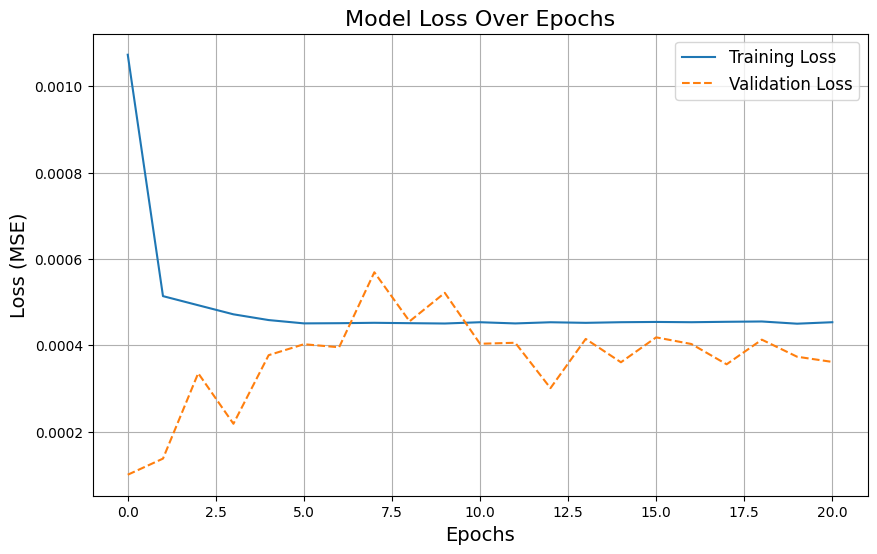

In [26]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Model Loss Over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss (MSE)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


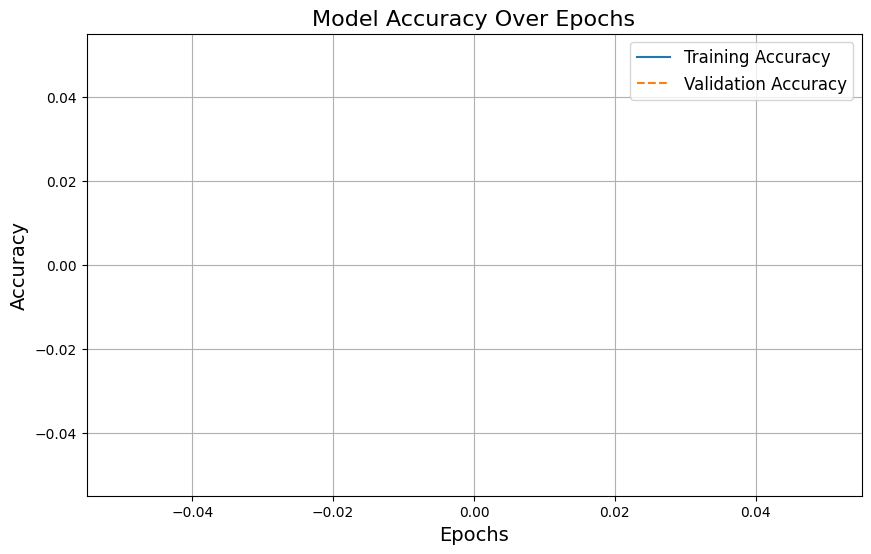

In [27]:
# Plot metrics if added during training
plt.figure(figsize=(10, 6))
plt.plot(history.history.get('accuracy', []), label='Training Accuracy')
plt.plot(history.history.get('val_accuracy', []), label='Validation Accuracy', linestyle='--')
plt.title('Model Accuracy Over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


In [39]:
# Define pollutant values for each region including SO2
regions_data = {
    'Saddar': {
        'PM2.5': 65,
        'PM10': 120,
        'NO2': 40,
        'NOx': 50,
        'NH3': 15,
        'NO': 30,
        'CO': 0.5,
        'Benzene': 5,
        'SO2': 10  # Example value for SO2
    },
    'Murree Road': {
        'PM2.5': 45,
        'PM10': 80,
        'NO2': 30,
        'NOx': 20,
        'NH3': 10,
        'NO': 25,
        'CO': 0.3,
        'Benzene': 3,
        'SO2': 8  # Example value for SO2
    },
    'Commercial Market': {
        'PM2.5': 85,
        'PM10': 150,
        'NO2': 50,
        'NOx': 60,
        'NH3': 20,
        'NO': 35,
        'CO': 0.7,
        'Benzene': 7,
        'SO2': 12  # Example value for SO2
    },
    'Faizabad': {
        'PM2.5': 55,
        'PM10': 90,
        'NO2': 25,
        'NOx': 15,
        'NH3': 12,
        'NO': 20,
        'CO': 0.4,
        'Benzene': 4,
        'SO2': 6  # Example value for SO2
    }
}

In [40]:
# Load your trained model
model = load_model('/content/aqi_deep_ann_model.keras')

# Calculate AQI for each region
aqi_values = {}
for region, pollutants in regions_data.items():
    input_data = pd.DataFrame([pollutants])
    predicted_aqi = model.predict(input_data)
    aqi_values[region] = predicted_aqi[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [41]:
# Example coordinates for Rawalpindi regions
regions_coordinates = {
    'Saddar': (33.6007, 72.6748),
    'Murree Road': (33.6100, 72.6750),
    'Commercial Market': (33.5900, 72.6800),
    'Faizabad': (33.5800, 72.6900)
}

In [44]:
import folium

# Create a base map centered around Rawalpindi
m = folium.Map(location=[33.6050, 72.6750], zoom_start=12)

# Function to determine color and remarks based on AQI
def get_aqi_color_and_remarks(aqi):
    if aqi <= 50:
        return 'green', 'Good'
    elif aqi <= 100:
        return 'yellow', 'Moderate'
    elif aqi <= 150:
        return 'orange', 'Unhealthy for Sensitive Groups'
    elif aqi <= 200:
        return 'red', 'Unhealthy'
    elif aqi <= 300:
        return 'purple', 'Very Unhealthy'
    else:
        return 'maroon', 'Hazardous'

# Example AQI values and coordinates for regions
regions_coordinates = {
    'Saddar': (33.6007, 72.6748),
    'Murree Road': (33.6100, 72.6750),
    'Commercial Market': (33.5900, 72.6800),
    'Faizabad': (33.5800, 72.6900)
}

aqi_values = {
    'Saddar': 45,  # Example AQI value
    'Murree Road': 75,
    'Commercial Market': 120,
    'Faizabad': 35
}

# Add markers for each region
for region, aqi in aqi_values.items():
    lat, lon = regions_coordinates[region]
    color, remarks = get_aqi_color_and_remarks(aqi)
    folium.CircleMarker(
        location=(lat, lon),
        radius=10,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        popup=f'<b>Region:</b> {region}<br><b>AQI:</b> {aqi}<br><b>Remarks:</b> {remarks}'
    ).add_to(m)

# Save or display the map
m.save('rawalpindi_air_quality_map.html')

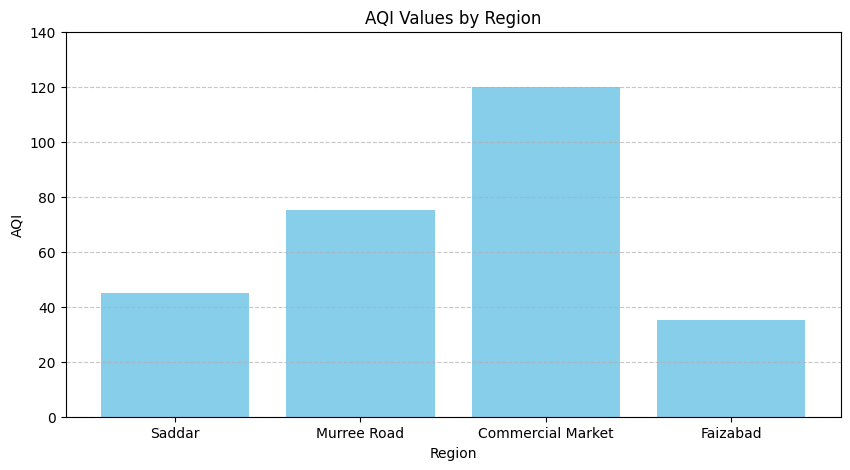

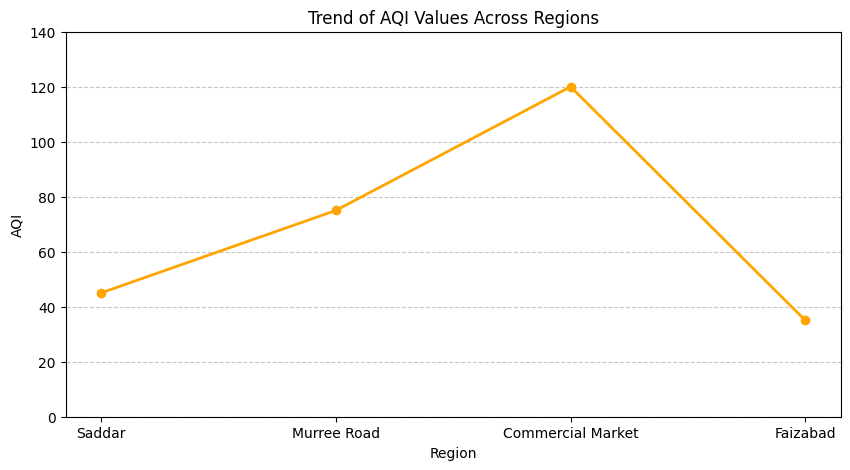

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# Example AQI values and coordinates for regions
regions = ['Saddar', 'Murree Road', 'Commercial Market', 'Faizabad']
aqi_values = [45, 75, 120, 35]  # Example AQI values

# Create a DataFrame
data = {
    'Region': regions,
    'AQI': aqi_values
}
df = pd.DataFrame(data)

# Bar Graph for AQI Values
plt.figure(figsize=(10, 5))
plt.bar(df['Region'], df['AQI'], color='skyblue')
plt.title('AQI Values by Region')
plt.xlabel('Region')
plt.ylabel('AQI')
plt.ylim(0, max(aqi_values) + 20)  # Set y-axis limit for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Line Graph for AQI Values
plt.figure(figsize=(10, 5))
plt.plot(df['Region'], df['AQI'], marker='o', color='orange', linestyle='-', linewidth=2)
plt.title('Trend of AQI Values Across Regions')
plt.xlabel('Region')
plt.ylabel('AQI')
plt.ylim(0, max(aqi_values) + 20)  # Set y-axis limit for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()